In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.io.arff import loadarff 

In [2]:
from sklearn.datasets import load_digits
digits = load_digits()
images = digits['images']
target = digits['target']
images.shape

(1797, 8, 8)

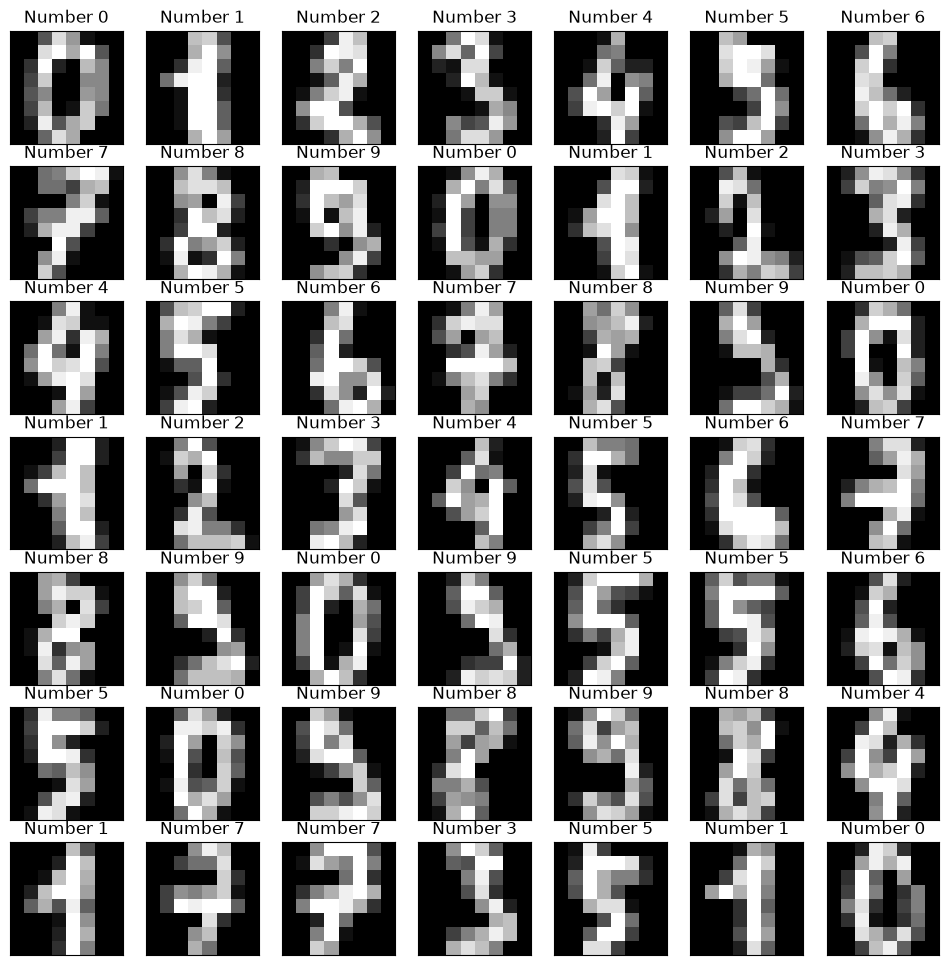

In [3]:
N = 7
fig, ax = plt.subplots(N, N, figsize=(12,12))
for i in range(N):
    for j in range(N):
        ax[i,j].set_title(f'Number {target[i*N+j]}')
        ax[i,j].imshow(images[i*N+j], cmap='gray')
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

images_flatten = np.reshape(images, (images.shape[0], 64))
X_train, X_test, y_train, y_test = train_test_split(images_flatten, target, 
                                                    test_size=0.2, random_state=42, shuffle=True)
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.975

### cross-validation

In [5]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=5, shuffle=False)
cv_score = cross_val_score(model, images_flatten, target, cv=cv)

cv_shuffle = KFold(n_splits=5, shuffle=True)
cv_score_shuffle = cross_val_score(model, images_flatten, target, cv=cv_shuffle)
cv_score_shuffle > cv_score

array([ True,  True,  True,  True,  True])

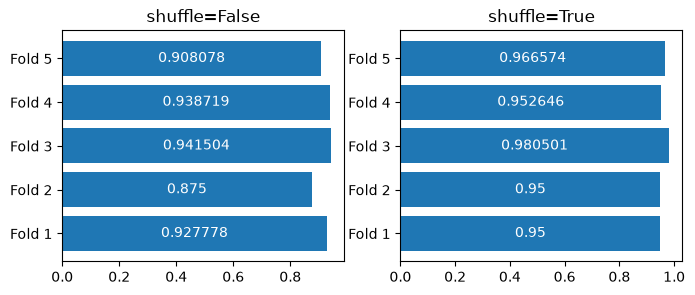

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(8,3))
ax[0].set_title('shuffle=False')
bars = ax[0].barh([f'Fold {i}' for i in range(1,cv.n_splits+1)], cv_score)
ax[0].bar_label(bars, label_type='center', color='white')
ax[1].set_title('shuffle=True')
bars_shuffle = ax[1].barh([f'Fold {i}' for i in range(1,cv_shuffle.n_splits+1)], cv_score_shuffle)
_ = ax[1].bar_label(bars_shuffle, label_type='center', color='white')

### evaluating model params based on cross_val res

In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

dataset = load_breast_cancer()
X, y = dataset.data, dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [8]:
models = [RandomForestClassifier(random_state=42, n_estimators=x) for x in [1, 20, 100, 500]]
cv_scores = [cross_val_score(model, X_train, y_train, cv=5) for model in models]
_ = [print(f'est {models[idx].n_estimators} => {cv_scores[idx].mean()}') for idx in range(len(models))]

est 1 => 0.9201915184678523
est 20 => 0.948344733242134
est 100 => 0.9600547195622434
est 500 => 0.9624076607387142


In [9]:
from sklearn.metrics import accuracy_score

final_model = models[-1]
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
accuracy_score(y_test, y_pred)

0.958041958041958

### cv on adult census dataset

In [10]:
data, metadata = loadarff("../datasets/adult_census.arff")
adult_census = pd.DataFrame(data)
# removing b' '
for col in adult_census.select_dtypes(include="object"):
    adult_census[col] = adult_census[col].str.decode("utf-8")
X = adult_census[['age', 'capital-gain', 'capital-loss', 'hours-per-week']]
y = adult_census['class']

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression())])
cv = KFold(n_splits=3, shuffle=False)
cv_score = cross_val_score(pipe, X, y, cv=cv).mean()
cv_score

np.float64(0.799701074258841)

k-fold manually

In [12]:
from sklearn.base import clone

def cv_scores(model, X, y, n):
    X = np.array(X)
    y = np.array(y)
    data_len = X.shape[0]
    in_fold_count = data_len//n
    remainder = data_len%n

    scores = []
    current_idx = 0
    for k in range(n):
        fold_size = in_fold_count + (1 if k < remainder else 0)
        idx_start = current_idx
        idx_end = current_idx + fold_size

        X_test = X[idx_start:idx_end]
        y_test = y[idx_start:idx_end]
                
        X_train = np.concatenate([X[:idx_start], X[idx_end:]], axis=0)
        y_train = np.concatenate([y[:idx_start], y[idx_end:]], axis=0)

        model_clone = clone(model)
        model_clone.fit(X_train, y_train)
        scores.append(model_clone.score(X_test, y_test))

        current_idx = idx_end
    return np.array(scores)

In [13]:
n_cv = 3
cv_score_my = cv_scores(pipe, X, y, n_cv).mean()
cv_score_my

np.float64(0.799701074258841)

In [14]:
cv_score == cv_score_my

np.True_